In [34]:
# @author: lajello
# Scaling and transforming data, with an example of how transformation 
# impacts the results of a linear regression

# REFERENCES:
# Examples of data scaling with sklearn: https://scikit-learn.org/stable/modules/preprocessing.html

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.stats

### Load data

In [36]:
df = pd.read_csv('us_states_geo.csv')
df.columns

Index(['state', 'state_code', 'capital', 'lat_centroid', 'lon_centroid',
       'neighboring_states', 'population', 'percentage_us_population',
       'democrat_2016', '%poor', 'unemployed', 'per capita income',
       'extraversion', 'agreeableness', 'conscientiousness', 'neuroticism',
       'openness', 'homicide rate (2017)', 'gdp_pc', 'high school or higher',
       'termperature', 'age-adjusted death rate (suicide)', 'marriage rate',
       'mdi', 'unemployment rate (2013)', 'median family income (2013)',
       'racial segregation (2013)', 'percent person of color (2013)',
       'gini-coefficient', 'firearm death rate', 'cultural tightness',
       'incarceration rate per 100,000 u.s. residents of all ages',
       'health_insurance_Medicaid', 'health_insurance_Medicare', 'uninsured',
       'twitter_user_count', 'twitter_tweet_count'],
      dtype='str')

### Log-transformations

In [37]:
# applying log transformation to some variables and saving them into new columns
df['pop_log'] = df['population'].apply(np.log)
df['edu_log'] = df['high school or higher'].apply(np.log)
df['twitter_user_count_log'] = df['twitter_user_count'].apply(np.log)

# in the next cells, plot distributions of variables before and after 
# transformation and relationship between them

<Axes: >

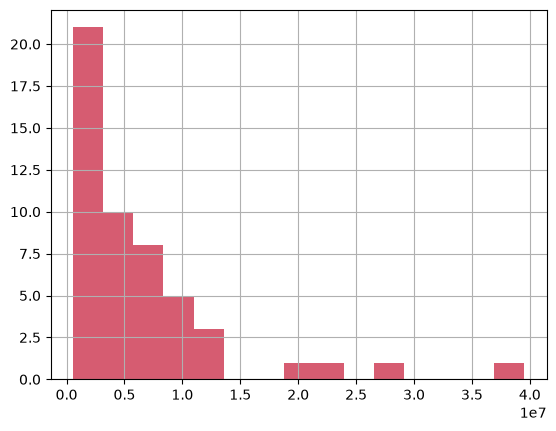

In [38]:
df['population'].hist(bins=15, color='#D65C71')

<Axes: >

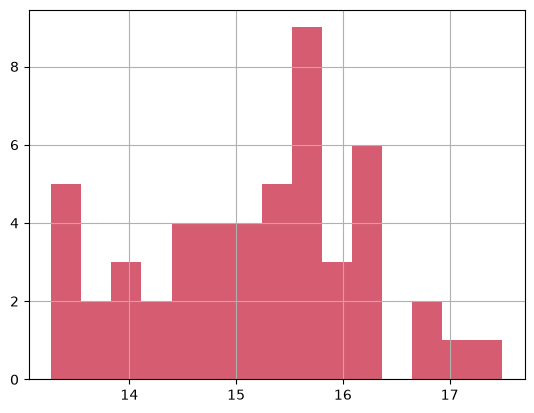

In [39]:
df['pop_log'].hist(bins=15,color='#D65C71')

<Axes: >

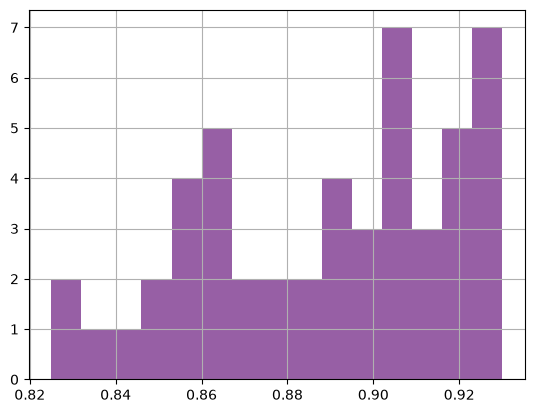

In [40]:
df['high school or higher'].hist(bins=15,color='#975FA5')

<Axes: >

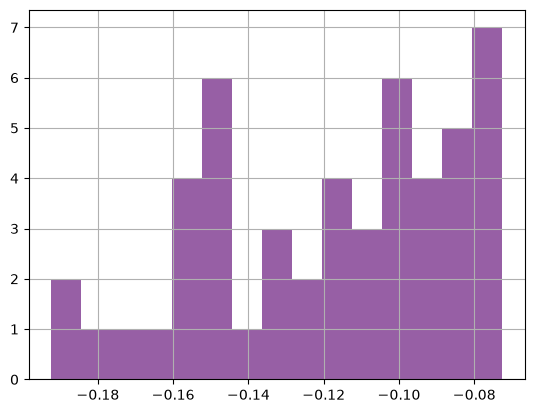

In [41]:
df['edu_log'].hist(bins=15,color='#975FA5')

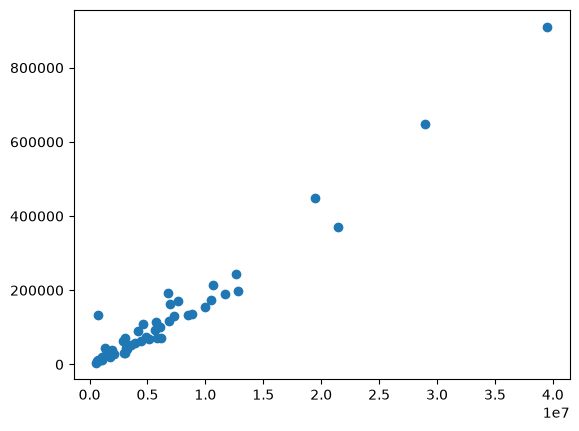

In [42]:
plt.scatter(df['population'], df['twitter_user_count'])

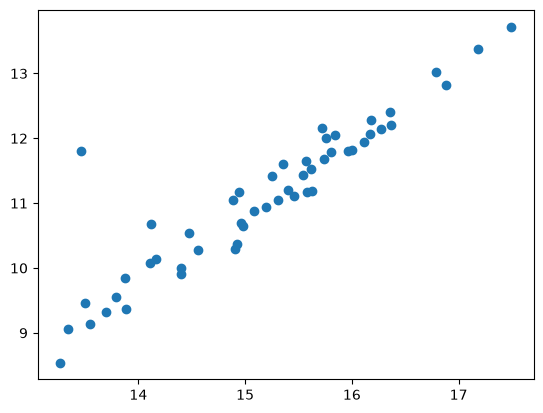

In [43]:
plt.scatter(df['pop_log'], df['twitter_user_count_log'])

### Boxcox and Q-Q plots

In [44]:
# compute boxcox transform on the population distribution
pop_boxcox, lambda_v =  scipy.stats.boxcox(df['population'])
df['pop_boxcox'] = pop_boxcox
print(f'Boxcox found that the optimal value for lambda is {lambda_v}')

Boxcox found that the optimal value for lambda is 0.0172511351656649


/var/folders/jf/0nvl5lz97m9gb6py4xb28b1c0000gn/T/ipykernel_66668/4080532869.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[0][0].set_xticklabels(['','0','1M','2M','3M','4M'])
/var/folders/jf/0nvl5lz97m9gb6py4xb28b1c0000gn/T/ipykernel_66668/4080532869.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[1][0].set_yticklabels(['','0','1M','2M','3M','4M'])


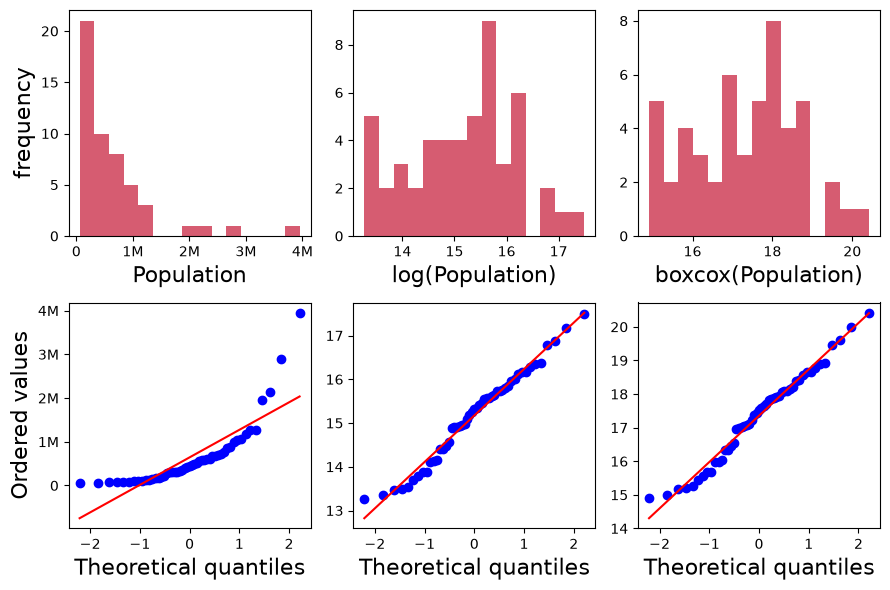

In [45]:
# initialize a plot with enough subplots to contain the charts we need
fig, axs = plt.subplots(2,3, figsize=(9,6))

# plot the distribution of the population variable and its two transformations
df['population'].hist(bins=15, ax=axs[0][0],color='#D65C71')
df['pop_log'].hist(bins=15, ax=axs[0][1],color='#D65C71')
df['pop_boxcox'].hist(bins=15, ax=axs[0][2],color='#D65C71')

# automatically plot the Q-Q plots for those distributions
scipy.stats.probplot(df['population'], dist='norm', plot=axs[1][0])
scipy.stats.probplot(df['pop_log'], dist='norm', plot=axs[1][1])
scipy.stats.probplot(df['pop_boxcox'], dist='norm', plot=axs[1][2])

# just some commands to beautify the plot
axs[0][0].grid(False)
axs[0][1].grid(False)
axs[0][2].grid(False)
axs[0][0].set_ylabel('frequency',fontsize=16)
axs[0][0].set_xlabel('Population',fontsize=16)
axs[0][0].set_xticklabels(['','0','1M','2M','3M','4M'])
axs[0][1].set_xlabel('log(Population)',fontsize=16)
axs[0][2].set_xlabel('boxcox(Population)',fontsize=16)
axs[1][0].set_yticklabels(['','0','1M','2M','3M','4M'])
axs[1][0].set_ylabel('Ordered values',fontsize=16)
axs[1][1].set_ylabel('')
axs[1][2].set_ylabel('')
axs[1][0].set_xlabel('Theoretical quantiles',fontsize=16)
axs[1][1].set_xlabel('Theoretical quantiles',fontsize=16)
axs[1][2].set_xlabel('Theoretical quantiles',fontsize=16)
axs[1][0].set_title('')
axs[1][1].set_title('')
axs[1][2].set_title('')
plt.tight_layout()

In [46]:
# EXCERCISE
# apply statistical tests to quantify which of the three distributions (original, log, boxcox) is normal

### Normalization & rescaling

In [47]:
# some packages to fit linear regression models
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS

In [48]:
# a utility function to perform linear regression
def do_linear_regression(X,Y):
    """
    Performs a OLS linear regression fit. 
    Some steps are not strictly required, they are reported just for showcasing
    @param X: independent variables
    @param Y: dependent variable
    @return the fit model
    """
    X = sm.add_constant(X) # add a constant (needed for the statsmodels package)
    model = sm.OLS(Y, X) # create a OLS object
    model = model.fit() # perform the fit
    R2_adj = model.rsquared_adj # calculate the goodness of fit
    influence = model.get_influence()
    standardized_residuals = influence.resid_studentized_internal # calculates the residuals 
    predicted_vals = model.predict(X) # predicted values of Y based on the linear best fit
    return model

In [ ]:
# select a variable you want to predict (dependent variable)
y_var = 'gini-coefficient'
# select N variables you want to use for prediction (independent variables)
x_vars = ['pop_log', 'edu_log']

# let's just drop the rows with null values, for simplicity
df_regr = df.dropna(subset=[y_var]+x_vars)

# extract the values from the dataframe and put them in two vectors
Y = df_regr[y_var]
X = df_regr[x_vars]

# EXERCISE
#pick different scaling functions and see how the regression results change
from sklearn.preprocessing import # .... insert here name of the desired module
X_scaled = 
Y_scaled = 
model = do_linear_regression(X_scaled, Y_scaled)
model.summary()

In [ ]:
# SOLUTION TO EXERCISE IS BELOW


























# SOLUTION TO PREVIOUS EXERCISE
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler() 
# X_scaled = scaler.fit_transform(np.array(X))
# Y_scaled = scaler.fit_transform(np.array(Y).reshape(-1, 1))
# model = do_linear_regression(X_scaled, Y_scaled)
# model.summary()